<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 01: Aritmética de Punto Flotante y Errores</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas Fuhrer y Manuel A. Sánchez | <b>Fecha:</b> 13 de Marzo, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>Familiarizarse con el entorno <b>Python + Numpy</b>.</li>
        <li>Entender las limitaciones de la representación <b>IEEE-754</b>.</li>
        <li>Analizar el <b>Épsilon de Máquina</b>.</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> Martín José Covarrubias Acevedo</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> 24626023</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.2
Estilo usado: <function context at 0x00000233BBC62AC0>


<div style="background-color:#fff8e1; border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría: El Estándar IEEE-754</h3>
    <p>En el computador, los números reales se aproximan usando notación científica binaria. Un número de doble precisión (64 bits) se representa como:</p>
    <p style="text-align: center; font-size: 1.2em;">
        $$x = (-1)^s \times (1.m) \times 2^{e - 1023}$$
    </p>
    <ul>
        <li><b>s (Signo):</b> 1 bit</li>
        <li><b>e (Exponente):</b> 11 bits</li>
        <li><b>m (Mantisa/Fracción):</b> 52 bits</li>
    </ul>
    <p>Esto implica que hay un límite en la precisión. El espacio entre el 1.0 y el siguiente número representable se llama <b>Épsilon de Máquina ($\epsilon_{mach}$)</b>.</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1: El Épsilon de Máquina</h3>
    <p>El épsilon de máquina es el número positivo más pequeño $\epsilon$ tal que:</p>
    <p style="text-align: center;">$$ 1.0 + \epsilon \neq 1.0 $$</p>
    <p><b>Tu tarea:</b></p>
    <ol>
        <li>Implementa un ciclo <code>while</code> que divida $\epsilon$ por 2 en cada paso hasta que el computador ya no pueda distinguir $1 + \epsilon$ de $1$.</li>
        <li>Imprime tu resultado calculado.</li>
        <li>Compáralo con el valor real almacenado en <code>sys.float_info.epsilon</code>.</li>
    </ol>
</div>

In [5]:
# 1. Tu implementación para calcular epsilon manualmente
eps = 1.0
contador = 0

while (1.0 + eps) > 1.0:
    eps = eps / 2.0
    contador += 1

# Nota: Al salir del ciclo, eps es tan pequeño que 1+eps = 1, 
# por lo que el último valor válido fue eps * 2
eps_calculado = eps * 2

print(f"Iteraciones: {contador}")
print(f"Epsilon calculado: {eps_calculado}")
print(f"Epsilon real (sys): {sys.float_info.epsilon}")

Iteraciones: 53
Epsilon calculado: 2.220446049250313e-16
Epsilon real (sys): 2.220446049250313e-16


<div style="background-color: #ffebee; border-left: 5px solid #f44336; padding: 15px; border-radius: 5px;">
    <h3 style="color: #c62828; margin-top: 0;">⚠️ Cancelación Catastrófica</h3>
    <p>Ocurre cuando restamos dos números muy cercanos entre sí. Los dígitos significativos se cancelan, dejando solo "ruido" numérico.</p>
    <p>Un ejemplo clásico es la evaluación de polinomios cerca de sus raíces o funciones trigonométricas con argumentos pequeños.</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 2: El Polinomio Ruidoso</h3>
    <p>Considere el polinomio $P(x) = (x - 1)^6$.</p>
    <p>Si expandimos este polinomio, obtenemos:</p>
    <p>$$ P(x) = x^6 - 6x^5 + 15x^4 - 20x^3 + 15x^2 - 6x + 1 $$</p>
    <p><b>Tu tarea:</b></p>
    <ol>
        <li>Crea un arreglo de <code>numpy</code> con 1000 puntos muy cercanos a 1 (ej: entre 0.995 y 1.005).</li>
        <li>Evalúa la versión factorizada: <code>y1 = (x - 1)**6</code>.</li>
        <li>Evalúa la versión expandida usando la fórmula polinómica completa.</li>
        <li>Grafica ambas curvas en el mismo gráfico. ¿Qué observas?</li>
    </ol>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

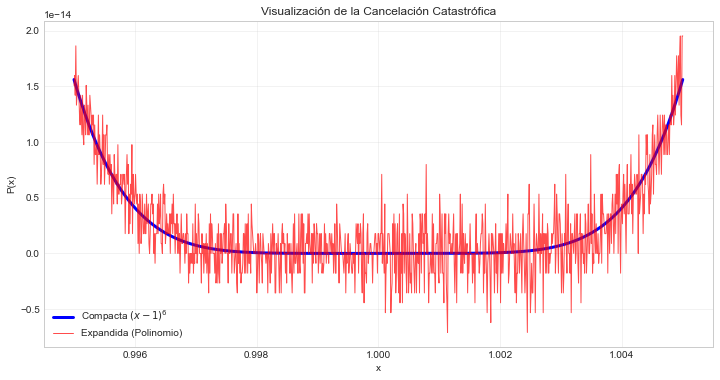

In [6]:
# Espacio para tu código

# 1. Definir dominio x
x = np.linspace(0.995, 1.005, 1000)

# 2. Evaluar forma compacta (Estable)
y_compacta = (x - 1)**6

# 3. Evaluar forma expandida (Inestable)
# Tip: Escribe la ecuación completa aquí
y_expandida = x**6 - 6*x**5 + 15*x**4 - 20*x**3 + 15*x**2 - 6*x + 1

# 4. Graficar
plt.figure(figsize=(12, 6))
plt.plot(x, y_compacta, label='Compacta $(x-1)^6$', linewidth=3, color='blue')
plt.plot(x, y_expandida, label='Expandida (Polinomio)', linewidth=1, color='red', alpha=0.7)

plt.title('Visualización de la Cancelación Catastrófica')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Thomas Fuhrer & Manuel A. Sánchez </strong><br>
        Profesores, <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT2605 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>